## predict the next word

In [174]:
import nltk

nltk.download('gutenberg')
from nltk.corpus import gutenberg

data = gutenberg.raw('shakespeare-hamlet.txt')


[nltk_data] Downloading package gutenberg to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package gutenberg is already up-to-date!


In [175]:
with open("shakespeare.txt", "w") as f:
    f.write(data)

## data precessing

In [176]:
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
import tensorflow as tf

In [203]:
with open("shakespeare.txt", 'r') as f:
    data = f.read().lower()

tokenizer = Tokenizer(num_words=8000,oov_token="<OOV>")
tokenizer.fit_on_texts([data])

In [204]:
tokenizer.word_index, tokenizer.index_word

({'<OOV>': 1,
  'the': 2,
  'and': 3,
  'to': 4,
  'of': 5,
  'i': 6,
  'you': 7,
  'a': 8,
  'my': 9,
  'it': 10,
  'in': 11,
  'that': 12,
  'ham': 13,
  'is': 14,
  'not': 15,
  'his': 16,
  'this': 17,
  'with': 18,
  'your': 19,
  'but': 20,
  'for': 21,
  'me': 22,
  'lord': 23,
  'as': 24,
  'what': 25,
  'he': 26,
  'be': 27,
  'so': 28,
  'him': 29,
  'haue': 30,
  'king': 31,
  'will': 32,
  'no': 33,
  'our': 34,
  'we': 35,
  'on': 36,
  'are': 37,
  'if': 38,
  'all': 39,
  'then': 40,
  'shall': 41,
  'by': 42,
  'thou': 43,
  'come': 44,
  'or': 45,
  'hamlet': 46,
  'good': 47,
  'do': 48,
  'hor': 49,
  'her': 50,
  'let': 51,
  'now': 52,
  'thy': 53,
  'how': 54,
  'more': 55,
  'they': 56,
  'from': 57,
  'enter': 58,
  'at': 59,
  'was': 60,
  'oh': 61,
  'like': 62,
  'most': 63,
  'there': 64,
  'well': 65,
  'know': 66,
  'selfe': 67,
  'would': 68,
  'them': 69,
  'loue': 70,
  'may': 71,
  "'tis": 72,
  'vs': 73,
  'sir': 74,
  'qu': 75,
  'which': 76,
  'did'

In [205]:
total_words = len(tokenizer.word_index) + 1
tokenizer.num_words

8000

In [180]:
input_sequences = []
for line in data.split('\n'):
    token_line = tokenizer.texts_to_sequences([line])[0]
    for i in range(len(token_line)):
        input_tokenized_line = token_line[:i + 1]
        input_sequences.append(input_tokenized_line)
input_sequences

[[2],
 [2, 688],
 [2, 688, 5],
 [2, 688, 5, 46],
 [2, 688, 5, 46, 42],
 [2, 688, 5, 46, 42, 1887],
 [2, 688, 5, 46, 42, 1887, 1888],
 [2, 688, 5, 46, 42, 1887, 1888, 1889],
 [1181],
 [1181, 1890],
 [1181, 1890, 1891],
 [1181, 1890, 1891, 1892],
 [58],
 [58, 408],
 [58, 408, 3],
 [58, 408, 3, 1182],
 [58, 408, 3, 1182, 178],
 [58, 408, 3, 1182, 178, 1893],
 [408],
 [408, 1183],
 [408, 1183, 64],
 [409],
 [409, 163],
 [409, 163, 378],
 [409, 163, 378, 22],
 [409, 163, 378, 22, 248],
 [409, 163, 378, 22, 248, 883],
 [19],
 [19, 67],
 [452],
 [452, 225],
 [452, 225, 249],
 [452, 225, 249, 2],
 [452, 225, 249, 2, 31],
 [409],
 [409, 408],
 [452],
 [452, 26],
 [409],
 [409, 7],
 [409, 7, 44],
 [409, 7, 44, 63],
 [409, 7, 44, 63, 1894],
 [409, 7, 44, 63, 1894, 97],
 [409, 7, 44, 63, 1894, 97, 19],
 [409, 7, 44, 63, 1894, 97, 19, 567],
 [452],
 [452, 72],
 [452, 72, 52],
 [452, 72, 52, 1895],
 [452, 72, 52, 1895, 568],
 [452, 72, 52, 1895, 568, 379],
 [452, 72, 52, 1895, 568, 379, 81],
 [452, 

## pad sequences

In [181]:
max_sequence_size = max(len(i) for i in input_sequences)
max_sequence_size

14

In [182]:
padded_input_seq = pad_sequences(input_sequences, maxlen=max_sequence_size, padding='pre')

In [183]:
X = padded_input_seq[:, :-1]
y = padded_input_seq[:, -1]
X.shape, y.shape


((29698, 13), (29698,))

In [184]:
y

array([   2,  688,    5, ..., 1048,    5,  194],
      shape=(29698,), dtype=int32)

In [185]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

## create LSTM model

In [186]:
import torch
import torch.nn as nn

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [206]:
class LSTM(nn.Module):
    def __init__(self, total_words_size, embed_dim, hidden_size, lstm_num_layers):
        super(LSTM, self).__init__()
        self.embedding_layer = nn.Embedding(num_embeddings=total_words_size, embedding_dim=embed_dim,)
        self.lstm = nn.LSTM(input_size=embed_dim, hidden_size=hidden_size, num_layers=lstm_num_layers, batch_first=True,dropout=0.3)
        self.fc = nn.Linear(in_features=hidden_size, out_features=total_words_size)

    def forward(self, x):
        embed = self.embedding_layer(x)
        lstm_output, (h_0, c_0) = self.lstm(embed)
        output = self.fc(h_0[-1])
        return output


lstm_1 = LSTM(total_words_size=total_words, embed_dim=64, hidden_size=64, lstm_num_layers=2).to(device)

In [207]:
loss_func = torch.nn.CrossEntropyLoss()
optim = torch.optim.Adam(lstm_1.parameters(),lr=0.003)

In [208]:
from torch.utils.data import DataLoader, TensorDataset

X_train = torch.tensor(X_train, dtype=torch.long)
y_train = torch.tensor(y_train, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=True)

C:\Users\PC\AppData\Local\Temp\ipykernel_16848\1871963736.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train = torch.tensor(X_train, dtype=torch.long)
C:\Users\PC\AppData\Local\Temp\ipykernel_16848\1871963736.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train = torch.tensor(y_train, dtype=torch.long)
C:\Users\PC\AppData\Local\Temp\ipykernel_16848\1871963736.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test = torch.tensor(X_test, dtype=torch.long)
C:\Users\PC\AppData\Local\Temp\ipykernel_16848\1871963736.py:6: Us

In [209]:
len(train_dataloader), len(test_dataloader)

(743, 186)

In [210]:
result = {
    'loss': [],
    'accuracy': [],
    "test_loss": [],
    "test_accuracy": []
}

In [211]:
def accuracy_func(y_pred, y_true):
    correct = torch.eq(y_pred, y_true).sum().item()
    accuracy = correct / len(y_pred)
    return accuracy

In [216]:
from tqdm.auto import tqdm

EPOCHS = 200

# training model
for epoch in tqdm(range(EPOCHS)):
    lstm_1.train()
    loss = 0
    accuracy = 0
    for X, y in train_dataloader:
        y_logits = lstm_1(X.to(device))

        batch_loss = loss_func(y_logits, y.to(device))

        optim.zero_grad()
        batch_loss.backward()
        optim.step()

        # calculate accuracy and loss
        y_prob = torch.softmax(y_logits, dim=1)
        y_pred = torch.argmax(y_prob, dim=1)
        batch_accuracy = accuracy_func(y_pred=y_pred, y_true=y.to(device))

        loss += batch_loss.item()
        accuracy += batch_accuracy

    # testing model
    with torch.inference_mode():
        lstm_1.eval()
        test_loss = 0
        test_accuracy = 0
        for X, y in test_dataloader:
            y_logits = lstm_1(X.to(device))
            batch_loss = loss_func(y_logits, y.to(device))
            test_loss += batch_loss.item()

            y_prob = torch.softmax(y_logits, dim=1)
            y_pred = torch.argmax(y_prob, dim=1)
            test_accuracy += accuracy_func(y_pred=y_pred, y_true=y.to(device))

    loss = loss / len(train_dataloader)
    accuracy = accuracy / len(train_dataloader)
    test_loss = test_loss / len(test_dataloader)
    test_accuracy = test_accuracy / len(test_dataloader)

    result['loss'].append(loss)
    result['accuracy'].append(accuracy)
    result['test_loss'].append(test_loss)
    result['test_accuracy'].append(test_accuracy)

    print(f"Epoch {epoch + 1}/{EPOCHS} loss: {loss} accuracy: {accuracy} test_loss: {test_loss} test_accuracy: {test_accuracy}")

torch.save(lstm_1.state_dict(), 'models/lstm_1.pth')

  0%|          | 1/200 [00:02<06:57,  2.10s/it]

Epoch 1/200 loss: 2.8045308161551987 accuracy: 0.38596543933858873 test_loss: 10.166472486270372 test_accuracy: 0.059475806451612906


  1%|          | 2/200 [00:03<06:30,  1.97s/it]

Epoch 2/200 loss: 2.8092287233347526 accuracy: 0.38744952893674295 test_loss: 10.182523773562524 test_accuracy: 0.06176075268817205


  2%|▏         | 3/200 [00:06<06:43,  2.05s/it]

...

Epoch 198/200 loss: 2.157655853763082 accuracy: 0.5068015766198808 test_loss: 13.25802593846475 test_accuracy: 0.05789650537634409


100%|█████████▉| 199/200 [06:46<00:02,  2.01s/it]

Epoch 199/200 loss: 2.138107017906004 accuracy: 0.5128581042107287 test_loss: 13.178661992472987 test_accuracy: 0.05420026881720431


100%|██████████| 200/200 [06:48<00:00,  2.04s/it]

Epoch 200/200 loss: 2.141524180910308 accuracy: 0.5127679773120554 test_loss: 13.189392348771454 test_accuracy: 0.058131720430107524


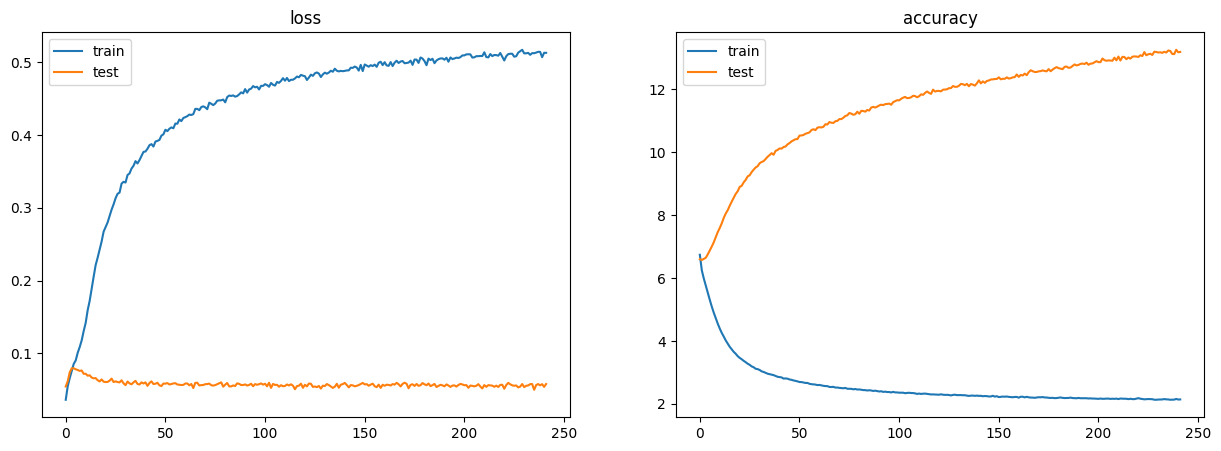

In [261]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1,2,figsize=(15,5))

ax[0].set_title("loss")
ax[0].plot(result['accuracy'], label='train')
ax[0].plot(result['test_accuracy'], label='test')
ax[0].legend()

ax[1].set_title("accuracy")
ax[1].plot(result['loss'], label='train')
ax[1].plot(result['test_loss'], label='test')
ax[1].legend()

plt.show()

In [223]:
import math
perplexity = math.exp(result['test_loss'][200])
perplexity

387155.8618103574

In [290]:
predict_seq = "Ghost. Do not forget: this Visitation"
tokenized_predict_seq = tokenizer.texts_to_sequences([predict_seq])[0]
tokenized_predict_padded_seq = pad_sequences([tokenized_predict_seq], maxlen=max_sequence_size)

X_pred = tokenized_predict_padded_seq[:,:-1]
y_pred = tokenized_predict_padded_seq[:,-1]

X_pred = torch.tensor(X_pred, dtype=torch.long).to(device)
y_pred = torch.tensor(y_pred, dtype=torch.long).to(device)

y_pred_logits = lstm_1(X_pred)
y_pred_probs = torch.softmax(y_pred_logits, dim=1)
y_model_pred = torch.argmax(y_pred_logits, dim=1)

print(f"input: {[tokenizer.index_word.get(word) for word in tokenized_predict_seq[:-1] ]}")
print(f"Model prediction: {tokenizer.index_word.get(y_model_pred[0].item())} \nTrue prediction: {tokenizer.index_word.get(y_pred.item())}")

input: ['ghost', 'do', 'not', 'forget', 'this']
Model prediction: visitation 
True prediction: visitation


In [280]:
y_pred

tensor([145], device='cuda:0')